In [1]:
from nilearn import datasets
import nibabel as nib
import numpy as np
from neuromaps import nulls, stats
from neuromaps import parcellate
from nilearn.maskers import NiftiLabelsMasker

# Load your wake and sleep group-level t-maps
wake_img = nib.load('/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/task-sleep_contrast-mreyemove_W-clean-with-fd-clamped-original-sleep/second_level_flame/flameo/stats/tstat1.nii.gz')
sleep_img = nib.load('/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/task-sleep_contrast-mreyemove_S-clean-with-fd-clamped-original-sleep/second_level_flame/flameo/stats/tstat1.nii.gz')

# Parcellate using Schaefer atlas (same one you used for FC)
parcellatew = datasets.fetch_atlas_schaefer_2018(n_rois=500).maps
destrieux = parcellate.Parcellater(parcellation, 'fsaverage').fit()
neurosynth_parc = destrieux.transform(neurosynth, 'fsaverage')
abagen_parc = destrieux.transform(abagen, 'fsaverage')

masker = NiftiLabelsMasker(labels_img=parc, standardize=False)
vals_wake = masker.fit_transform(wake_img).squeeze()   # (500,)
vals_sleep = masker.fit_transform(sleep_img).squeeze()

# Generate spatial-autocorrelation-preserving null maps for wake
null_maps = nulls.burt2020(
  vals_wake,
  atlas='mni152',
  density='2mm',
  parcellation=parc,
  n_perm=5,
  seed=42,
  n_proc=6,
)

# Compare: observed r + p-value against null
corr, pval = stats.compare_images(vals_wake, vals_sleep, nulls=null_maps)
print(f'r = {corr:.3f}, p_spin = {pval:.4f}')


/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


[fetch_atlas_schaefer_2018] Dataset found in /Users/zach/nilearn_data/schaefer_2018


KeyboardInterrupt: 

In [20]:
import numpy as np
import pandas as pd

# df = pd.read_pickle("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/eeg/mean_eog_reg.p")
# df

df = pd.read_pickle("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/eeg/mean_eog_reg.p")
eog_data = df
subject = "10"
run = 1
eog_run_df = eog_data[
                    (eog_data["subject"] == subject) & (eog_data["run"] == run)
                ].reset_index(drop=True)
eog_run = eog_run_df["signal"].to_numpy()
eog_run


array([], dtype=float64)

In [4]:
A = np.abs(np.diff((X - Y)))
B = np.diff(np.abs((X - Y)))
np.all(A == B)

False

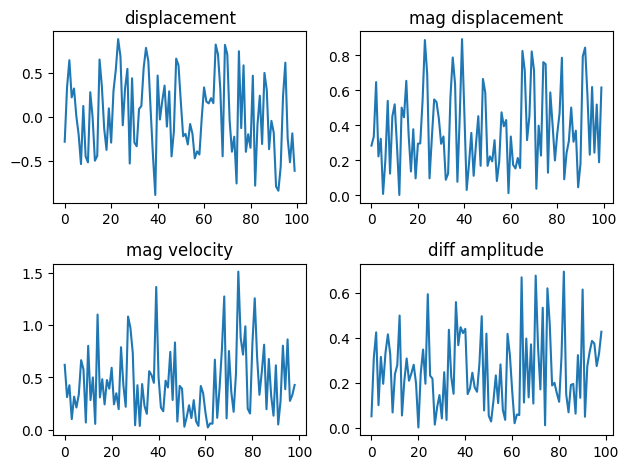

In [16]:
from matplotlib import pyplot as plt

f, axs = plt.subplots(nrows=2, ncols=2)
axs[0,0].plot(X-Y)
axs[0,0].set_title('displacement')

axs[0,1].plot(np.abs(X-Y))
axs[0,1].set_title('mag displacement')

axs[1,0].plot(np.abs(np.diff(X-Y)))
axs[1,0].set_title('mag velocity')


axs[1,1].plot(np.abs(np.diff(np.abs(X-Y))))
axs[1,1].set_title('diff amplitude')
plt.tight_layout()

In [1]:
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    # exclude_subjects=["01", "02", "12", "21", "07", "11", "13", "31"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    load_eog=False,
    desc_add="clean-with-fd-clamped",
)

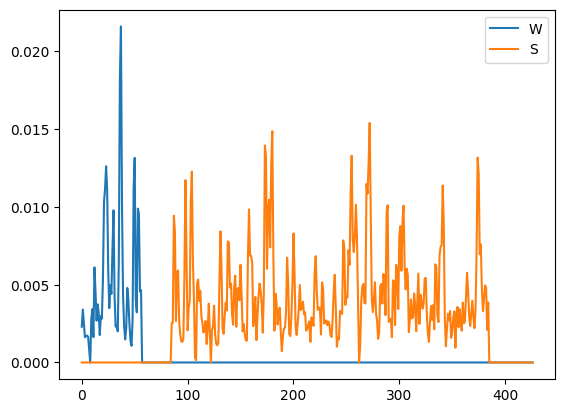

In [8]:
from matplotlib import pyplot as plt
subject = "28"
run = 3

df = mrio.events[(mrio.events["subject"]==subject) & (mrio.events["run"]==run)].reset_index(drop=True)
plt.plot(df["mreyemove_W"], label="W")
plt.plot(df["mreyemove_S"], label="S")
# plt.plot(df["mreyemove_trans"], color="r", label="trans")
plt.legend()

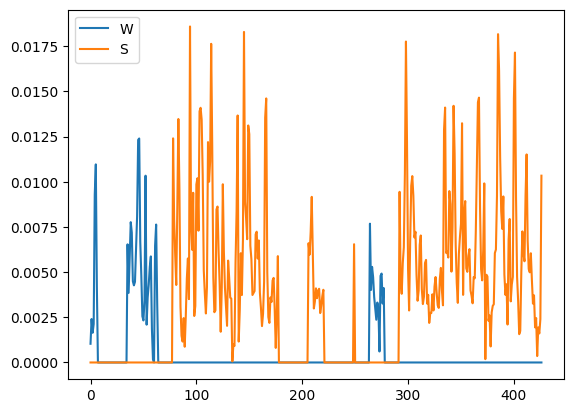

In [2]:
from matplotlib import pyplot as plt
subject = "17"
run = 3

df = mrio.events[(mrio.events["subject"]==subject) & (mrio.events["run"]==run)].reset_index(drop=True)
plt.plot(df["mreyemove_W"], label="W")
plt.plot(df["mreyemove_S"], label="S")
plt.legend()

In [17]:
subject_fd_means = {}
for subject, run, run_df in mrio.iter_run_events(run_inclusion=True): 
    df = mrio.load_confounds(subject=subject, run=run, confound_names=["framewise_displacement"])
    subject_fd_means.setdefault(subject, []).append(df["framewise_displacement"].mean())
    

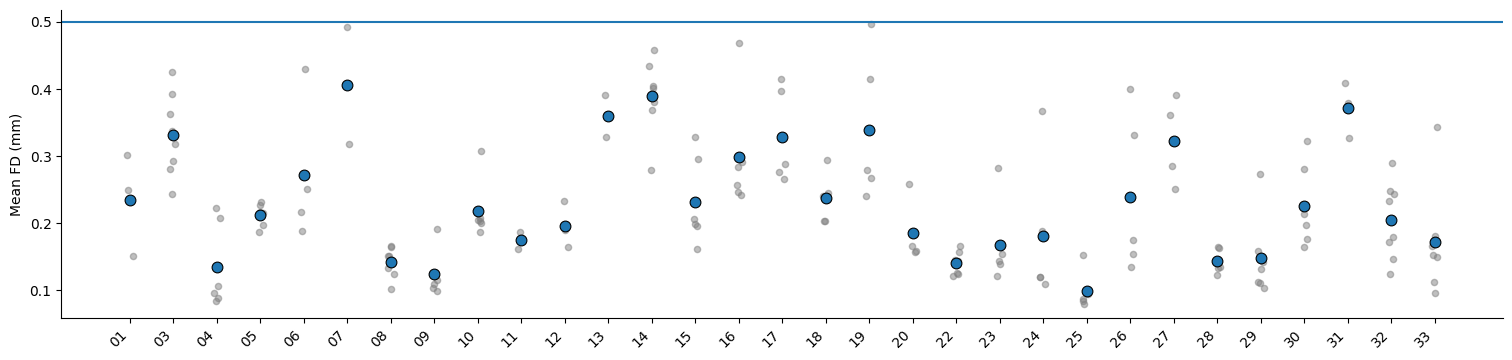

In [24]:

from matplotlib import pyplot as plt
import numpy as np 

data = subject_fd_means
jitter=0.08
fig, ax = plt.subplots(figsize=(max(4, 0.6 * len(data)), 4))

subjects = list(data.keys())

for i, subj in enumerate(subjects):
    vals = np.asarray(data[subj], dtype=float)
    if len(vals) < 2:
        print(f"Skipping subject {subj} with too few runs {len(vals)}")
        continue
    x = i + np.random.uniform(-jitter, jitter, size=vals.size)
    ax.scatter(x, vals, alpha=0.5, color='gray', s=20, zorder=1)
    ax.scatter(i, vals.mean(), color='C0', s=60, zorder=2,
               edgecolor='black', linewidth=0.8)

ax.axhline(0.5)
ax.set_xticks(range(len(subjects)))
ax.set_xticklabels(subjects, rotation=45, ha='right')
ax.set_ylabel('Mean FD (mm)')
ax.spines[['top', 'right']].set_visible(False)

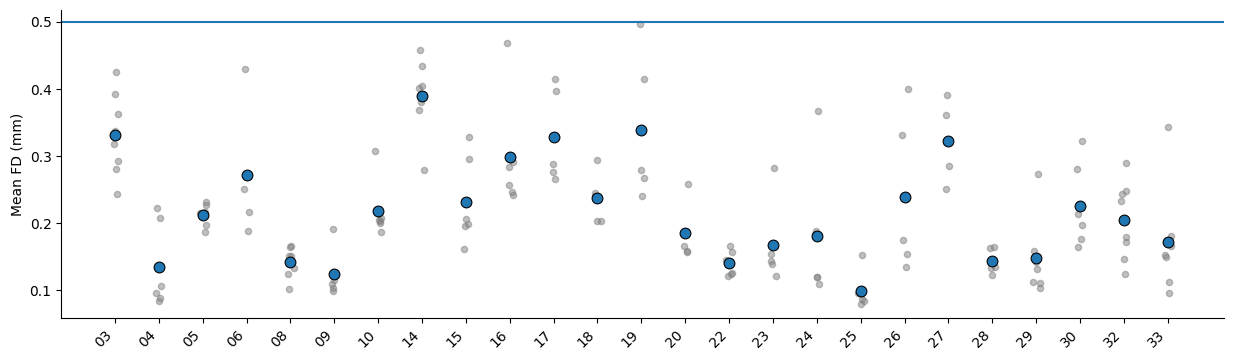

In [11]:

from matplotlib import pyplot as plt
import numpy as np 

data = subject_fd_means
jitter=0.08
fig, ax = plt.subplots(figsize=(max(4, 0.6 * len(data)), 4))

subjects = list(data.keys())

for i, subj in enumerate(subjects):
    vals = np.asarray(data[subj], dtype=float)
    if len(vals) < 4:
        print(f"Skipping subject {subj} with too few runs")
        continue
    x = i + np.random.uniform(-jitter, jitter, size=vals.size)
    ax.scatter(x, vals, alpha=0.5, color='gray', s=20, zorder=1)
    ax.scatter(i, vals.mean(), color='C0', s=60, zorder=2,
               edgecolor='black', linewidth=0.8)

ax.axhline(0.5)
ax.set_xticks(range(len(subjects)))
ax.set_xticklabels(subjects, rotation=45, ha='right')
ax.set_ylabel('Mean FD (mm)')
ax.spines[['top', 'right']].set_visible(False)

In [3]:
for subj, vals in subject_fd_means.items():
    if len(vals) < 4:
        print(subj)

07
11
13
31


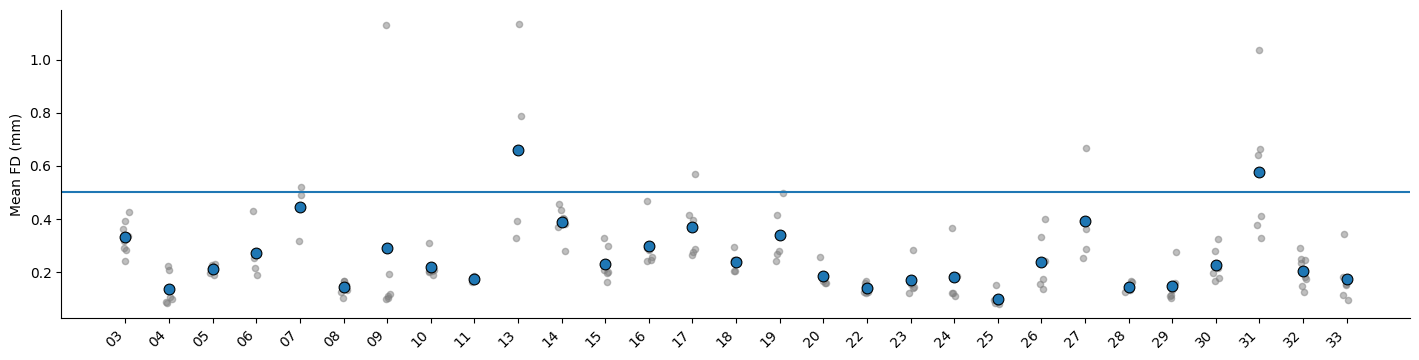

In [27]:
from matplotlib import pyplot as plt
import numpy as np 

data = subject_fd_means
jitter=0.08
fig, ax = plt.subplots(figsize=(max(4, 0.6 * len(data)), 4))

subjects = list(data.keys())
for i, subj in enumerate(subjects):
    vals = np.asarray(data[subj], dtype=float)
    x = i + np.random.uniform(-jitter, jitter, size=vals.size)
    ax.scatter(x, vals, alpha=0.5, color='gray', s=20, zorder=1)
    ax.scatter(i, vals.mean(), color='C0', s=60, zorder=2,
               edgecolor='black', linewidth=0.8)

ax.axhline(0.5)
ax.set_xticks(range(len(subjects)))
ax.set_xticklabels(subjects, rotation=45, ha='right')
ax.set_ylabel('Mean FD (mm)')
ax.spines[['top', 'right']].set_visible(False)

In [29]:
subject_fd_means["19"]

[0.23981978272380972,
 0.27864347008524626,
 0.2675561458893503,
 0.41467917175498337,
 0.49676878884427195]

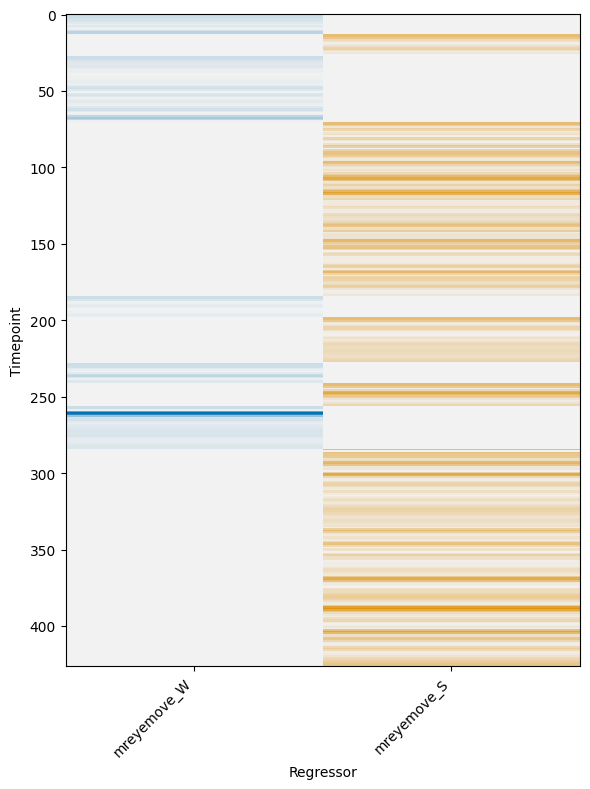

In [36]:
from matplotlib.colors import LinearSegmentedColormap
from mreyemove.analysis.glm.first_level import build_design_matrix
from mreyemove.analysis.glm.cli import construct_desc
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO
from mreyemove.analysis.glm.config import GLMConfig
from nilearn import plotting 
from matplotlib import pyplot as plt
subject = "17"
run = 3

config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)
df = mrio.events 
run_events = df[(df["subject"] == subject) & (df["run"] == run)]

X = build_design_matrix(
    dataset=mrio,
    subject=subject,
    run=run,
    run_events=run_events,
    config=config,
)



def make_cmap(hex_color, background="#f2f2f2ff", name=None):
    """White (or other bg) -> hex_color colormap."""
    return LinearSegmentedColormap.from_list(
        name or hex_color, [background, hex_color]
    )


use_abs = True
n_regs = 0
hex_colors = ["#0173b2ff", "#de8f05f2",] + ["#888888"] * (n_reg - 2)

fig, ax = plt.subplots(figsize=(6, 8))
X = X.iloc[:, 0:2+n_regs]
n_tp, n_reg = X.shape
# if hex_colors is None:
#     A, B, then nuisance regressors in grey
    # hex_colors = ["#1f6feb", "#d1242f"] + ["#888888"] * (n_reg - 2)

cmaps = [make_cmap(c) for c in hex_colors]

# cmaps = ["Blues", "Reds"] + ["Greys"] * (n_reg - 2)


for i, (col, cmap) in enumerate(zip(X.columns, cmaps)):
    vals = X[col].values
    data = np.abs(vals) if use_abs else vals
    vmax = np.abs(vals).max() or 1.0  # avoid vmax=0 for empty cols
    ax.imshow(
        data[:, None],
        aspect="auto",
        cmap=cmap,
        vmin=0 if use_abs else -vmax,
        vmax=vmax,
        extent=(i - 0.5, i + 0.5, n_tp - 0.5, -0.5),
        interpolation="nearest",
    )

ax.set_xlim(-0.5, n_reg - 0.5)
ax.set_ylim(n_tp - 0.5, -0.5)
ax.set_xticks(range(n_reg))
ax.set_xticklabels(X.columns, rotation=45, ha="right")
ax.set_xlabel("Regressor")
ax.set_ylabel("Timepoint")
plt.tight_layout()
# X
# plotting.plot_design_matrix(X,rescale=True)

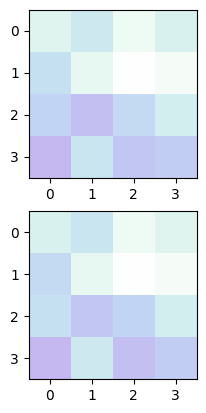

In [70]:

from scipy.stats import rankdata
import numpy as np



def correlated_matrices(rho, size=4, value_range=(0, 1), seed=None):
    """
    Two `size` x `size` matrices with entries bounded in `value_range`
    and flattened Pearson/Spearman correlation near `rho`.

    Construction:
      1. Draw A, noise ~ N(0, 1), standardized.
      2. B = rho * A + sqrt(1 - rho^2) * noise.
      3. Map each matrix to uniform ranks in [0, 1], then scale to range.
         This bounds outputs exactly and preserves rank correlation.
    """
    if not -1 <= rho <= 1:
        raise ValueError("rho must be in [-1, 1].")
    low, high = value_range
    if high <= low:
        raise ValueError("value_range must be (low, high) with high > low.")

    rng = np.random.default_rng(seed)

    def standardize(x):
        return (x - x.mean()) / x.std()

    A = standardize(rng.standard_normal((size, size)))
    noise = standardize(rng.standard_normal((size, size)))
    B = rho * A + np.sqrt(1 - rho**2) * noise

    def to_range(x):
        # Rank-based mapping -> uniform on (0, 1), then rescale.
        # Using (rank - 0.5) / n puts values strictly inside (0, 1).
        n = x.size
        u = (rankdata(x, method="average").reshape(x.shape) - 0.5) / n
        return low + u * (high - low)

    return to_range(A), to_range(B)


r = 0.3
A, B = correlated_matrices(rho=0.99, size=4, seed=0, value_range=(0.5, 1))

f, axs = plt.subplots(2,1)

axs[0].imshow(A, cmap="cubehelix", vmin=-1, vmax=1)
axs[1].imshow(B, cmap="cubehelix", vmin=-1, vmax=1)


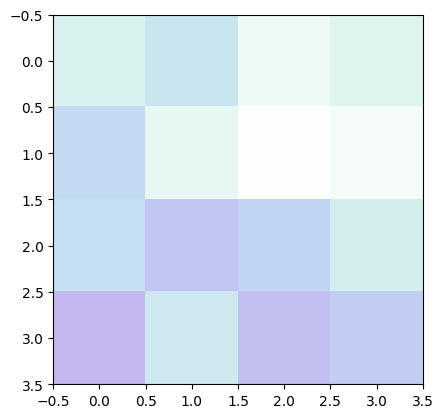

In [72]:
plt.imshow(B,  cmap="cubehelix", vmin=-1, vmax=1)

/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



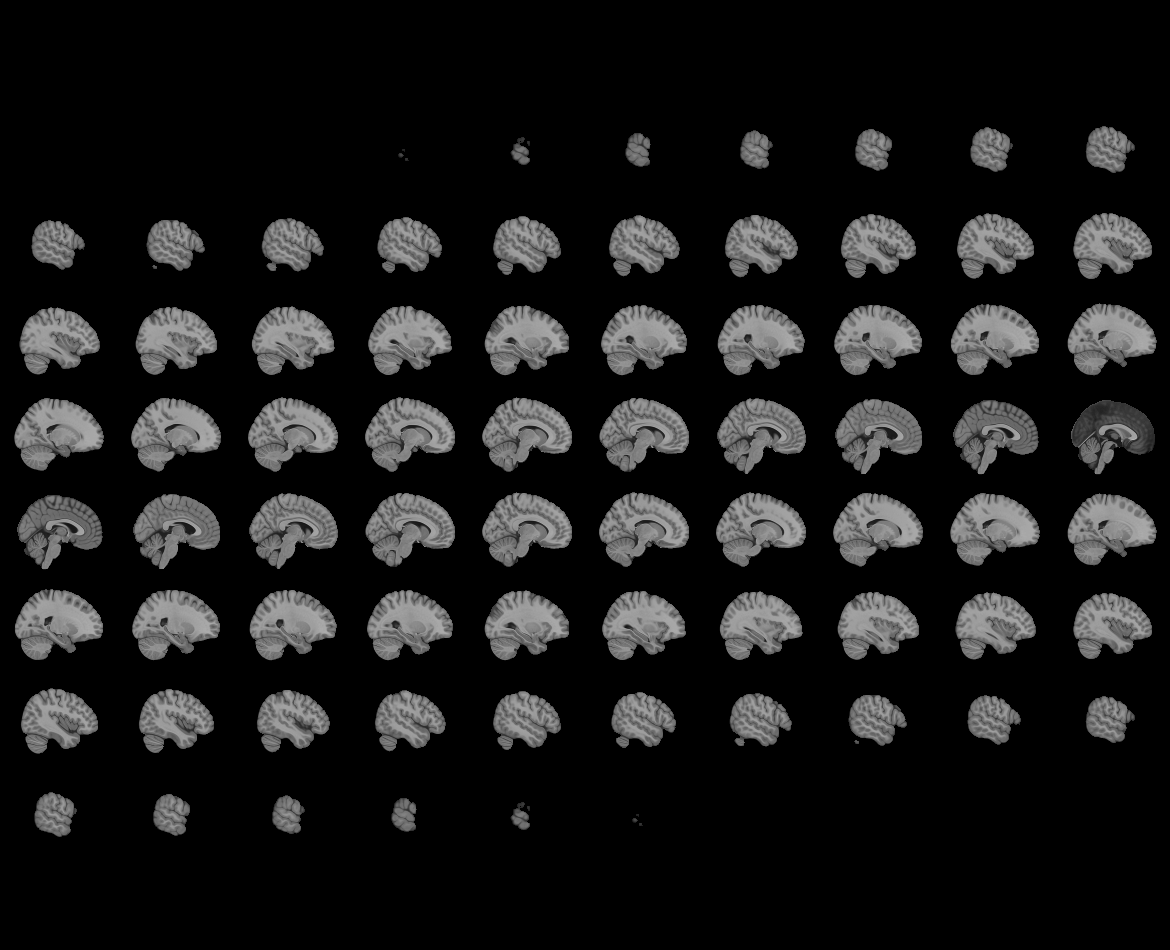
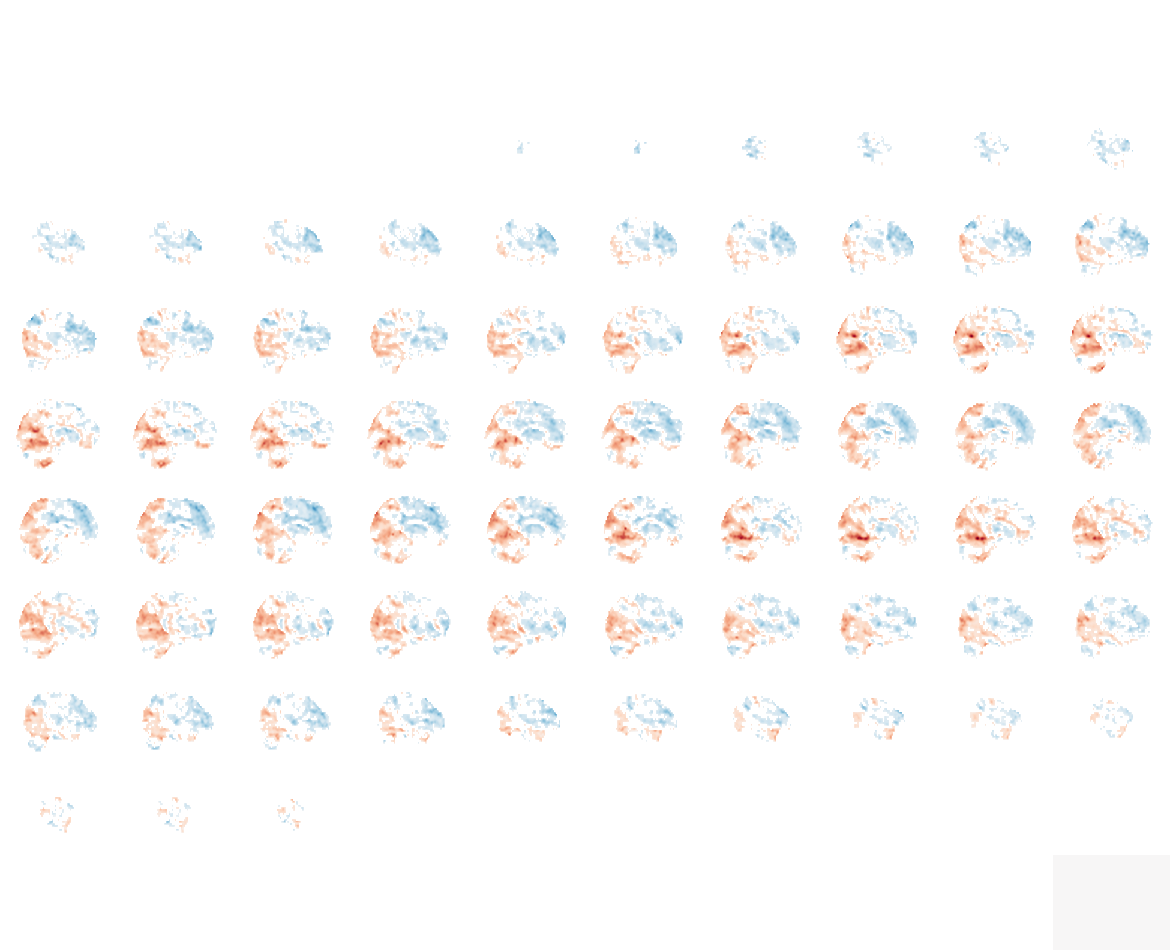

In [3]:

from nilearn import plotting 
tmap_path = '/Users/zach/2025_RA/matthias/final images/tmaps/sleep_tmap_group.nii.gz'

plotting.view_img(tmap_path, threshold=1)